# Meteorological Feature Overlap Analysis

**Comprehensive Analysis of MCS, AR, and ETC Interactions**

This notebook implements a scientifically robust framework for analyzing overlaps between:
- **MCS (Mesoscale Convective Systems)**: Smallest scale features
- **AR (Atmospheric Rivers)**: Medium scale features  
- **ETC (Extratropical Cyclones)**: Largest scale features

## Key Features:
- **Meteorologically-informed thresholds** respecting atmospheric scale hierarchy
- **Pair-based filtering** ensuring visual consistency
- **Vectorized overlap detection** for efficiency
- **Comprehensive visualization** of 2-way and 3-way interactions

## Threshold Design:
- **2-way overlaps**: MCS=20%, AR=10%, ETC=5%
- **3-way overlaps**: MCS=20%, AR=10%, ETC=0% (environmental context)

In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# LOAD DATA
# Update these paths as needed for your data location
# in_dir = '/global/cfs/cdirs/m1867/zfeng/PyFLEXTRKR/quicklook_dev/sample_data'
# root_dir = '/global/homes/f/feng045/program/hackathon/hk25-teams/hk25-Tracking'
# figdir = f'{root_dir}/figures'

source_name = "scream"
root_dir = "/pscratch/sd/w/wcmca1/hackathon/allmasks/"
in_dir = f"{root_dir}/{source_name}_allmasks_hp8_v1.zarr"

figdir = "/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/"
# figdir = "/pscratch/sd/w/wcmca1/hackathon/"
os.makedirs(figdir, exist_ok=True)

# Load the processed dataset
print(f"Loading data from: {in_dir}")

ds = xr.open_dataset(in_dir)
ds = ds.pipe(egh.attach_coords)
ds

Loading data from: /pscratch/sd/w/wcmca1/hackathon/allmasks//scream_allmasks_hp8_v1.zarr


<xarray.Dataset> Size: 49GB
Dimensions:   (time: 3138, cell: 786432)
Coordinates:
  * time      (time) datetime64[ns] 25kB 2019-08-01T03:00:00 ... 2020-09-01
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ar_mask   (time, cell) int32 10GB ...
    etc_mask  (time, cell) int32 10GB ...
    mcs_mask  (time, cell) float64 20GB ...
    tc_mask   (time, cell) int32 10GB ...
Attributes: (12/37)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tb_threshold_core:            225.0
    tb_threshold_environment:     261.0
    tb_threshold_warmanvil:       261.0
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [3]:
# tm = '2019-11-24T03'
# tm = '2019-11-26T06'
tm = '2019-11-27T06'

# Select single time step first
_ds = ds.sel(time=tm, method='nearest')

print(f"Dataset loaded successfully!")
print(f"Data variables: {list(_ds.data_vars)}")
print(f"Spatial dimensions: {_ds.dims}")

# Display basic statistics
n_mcs = len(np.unique(_ds.mcs_mask.values[_ds.mcs_mask.values > 0]))
n_ar = len(np.unique(_ds.ar_mask.values[_ds.ar_mask.values > 0]))
n_etc = len(np.unique(_ds.etc_mask.values[_ds.etc_mask.values > 0]))

print(f"\nFeature counts:")
print(f"  MCS tracks: {n_mcs}")
print(f"  AR tracks: {n_ar}")
print(f"  ETC tracks: {n_etc}")

Dataset loaded successfully!
Data variables: ['ar_mask', 'etc_mask', 'mcs_mask', 'tc_mask']
Spatial dimensions: FrozenMappingWarningOnValuesAccess({'cell': 786432})

Feature counts:
  MCS tracks: 92
  AR tracks: 10
  ETC tracks: 6


## Visualize all masks

In [4]:
def plot_all_feature_masks(ds, title="", figsize=(12, 6), colors=None, figname=None, dpi=200, 
                          alphas=None, title_fontsize=14, legend_fontsize=12, 
                          show_track_labels=True, track_fontsize=8):
    """
    Plot all 4 feature masks at a single time step with optional track labels.
    
    Parameters:
    - ds: xarray Dataset containing the mask variables (assumes single time step)
    - title: optional title for the plot
    - figsize: figure size tuple
    - colors: dict with color names for each feature type, e.g. {'mcs': 'lightskyblue', 'ar': 'orange', 'etc': 'lightgreen', 'tc': 'lightcoral'}
    - figname: if provided, save figure as PNG with this filename
    - dpi: DPI for figure display and saving (default 200)
    - alphas: dict with alpha values for each feature type, e.g. {'mcs': 0.6, 'ar': 0.7, 'etc': 0.5, 'tc': 0.8}
    - title_fontsize: font size for the plot title (default 14)
    - legend_fontsize: font size for the legend (default 12)
    - show_track_labels: whether to show track ID labels for ETC and AR features (default True)
    - track_fontsize: font size for track labels (default 8)
    
    Returns:
    - fig, ax: matplotlib figure and axes objects
    """
    # Set default colors
    if colors is None:
        colors = {
            'mcs': 'lightskyblue',
            'ar': 'orange', 
            'etc': 'lightgreen',
            'tc': 'lightcoral'
        }
    
    # Set default alphas
    if alphas is None:
        alphas = {
            'mcs': 0.6,
            'ar': 0.6,
            'etc': 0.6,
            'tc': 0.6
        }
    
    # Create base map (integrated from worldmap_base)
    projection = ccrs.Robinson(central_longitude=-135)
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection},
        constrained_layout=True
    )
    fig.dpi = dpi
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else "Feature Masks"
    ax.set_title(plot_title, fontsize=title_fontsize)
    
    # Extract masks (assuming single time step)
    mcs_mask = ds['mcs_mask'].squeeze()
    ar_mask = ds['ar_mask'].squeeze()
    etc_mask = ds['etc_mask'].squeeze()
    tc_mask = ds['tc_mask'].squeeze()
    
    # Convert masks to binary (all features = 1, no features = 0)
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    
    # Plot MCS mask with customizable color and alpha
    if np.any(mcs_binary > 0):
        img_mcs = egh.healpix_show(
            mcs_binary.where(mcs_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['mcs']]), 
            alpha=alphas['mcs'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot AR mask with customizable color and alpha
    if np.any(ar_binary > 0):
        img_ar = egh.healpix_show(
            ar_binary.where(ar_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['ar']]), 
            alpha=alphas['ar'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot ETC mask with customizable color and alpha
    if np.any(etc_binary > 0):
        img_etc = egh.healpix_show(
            etc_binary.where(etc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['etc']]), 
            alpha=alphas['etc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot TC mask with customizable color and alpha
    if np.any(tc_binary > 0):
        img_tc = egh.healpix_show(
            tc_binary.where(tc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['tc']]), 
            alpha=alphas['tc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Add track labels for ETC and AR features if requested
    if show_track_labels:
        # Helper function for circular longitude averaging (handles dateline crossing)
        def circular_lon_mean(lon_values):
            """Calculate circular mean for longitude values to handle dateline crossing."""
            # Convert to radians
            lon_rad = np.deg2rad(lon_values)
            # Calculate circular mean using complex numbers
            mean_complex = np.mean(np.exp(1j * lon_rad))
            # Convert back to degrees and ensure 0-360 range
            mean_lon = np.rad2deg(np.angle(mean_complex))
            if mean_lon < 0:
                mean_lon += 360
            return mean_lon
        
        # Add ETC track labels (green)
        etc_tracks = np.unique(etc_mask.values[etc_mask.values > 0])
        for track_id in etc_tracks:
            track_pixels = (etc_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='green', ha='center', va='center')
        
        # Add AR track labels (darkorange)
        ar_tracks = np.unique(ar_mask.values[ar_mask.values > 0])
        for track_id in ar_tracks:
            track_pixels = (ar_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='darkorange', ha='center', va='center')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=colors['mcs'], alpha=alphas['mcs'], label='MCS'),
        Patch(facecolor=colors['ar'], alpha=alphas['ar'], label='AR'),
        Patch(facecolor=colors['etc'], alpha=alphas['etc'], label='ETC'),
        Patch(facecolor=colors['tc'], alpha=alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.99), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")
    
    return fig, ax

Figure saved as /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_allmasks_20191127_0600.png


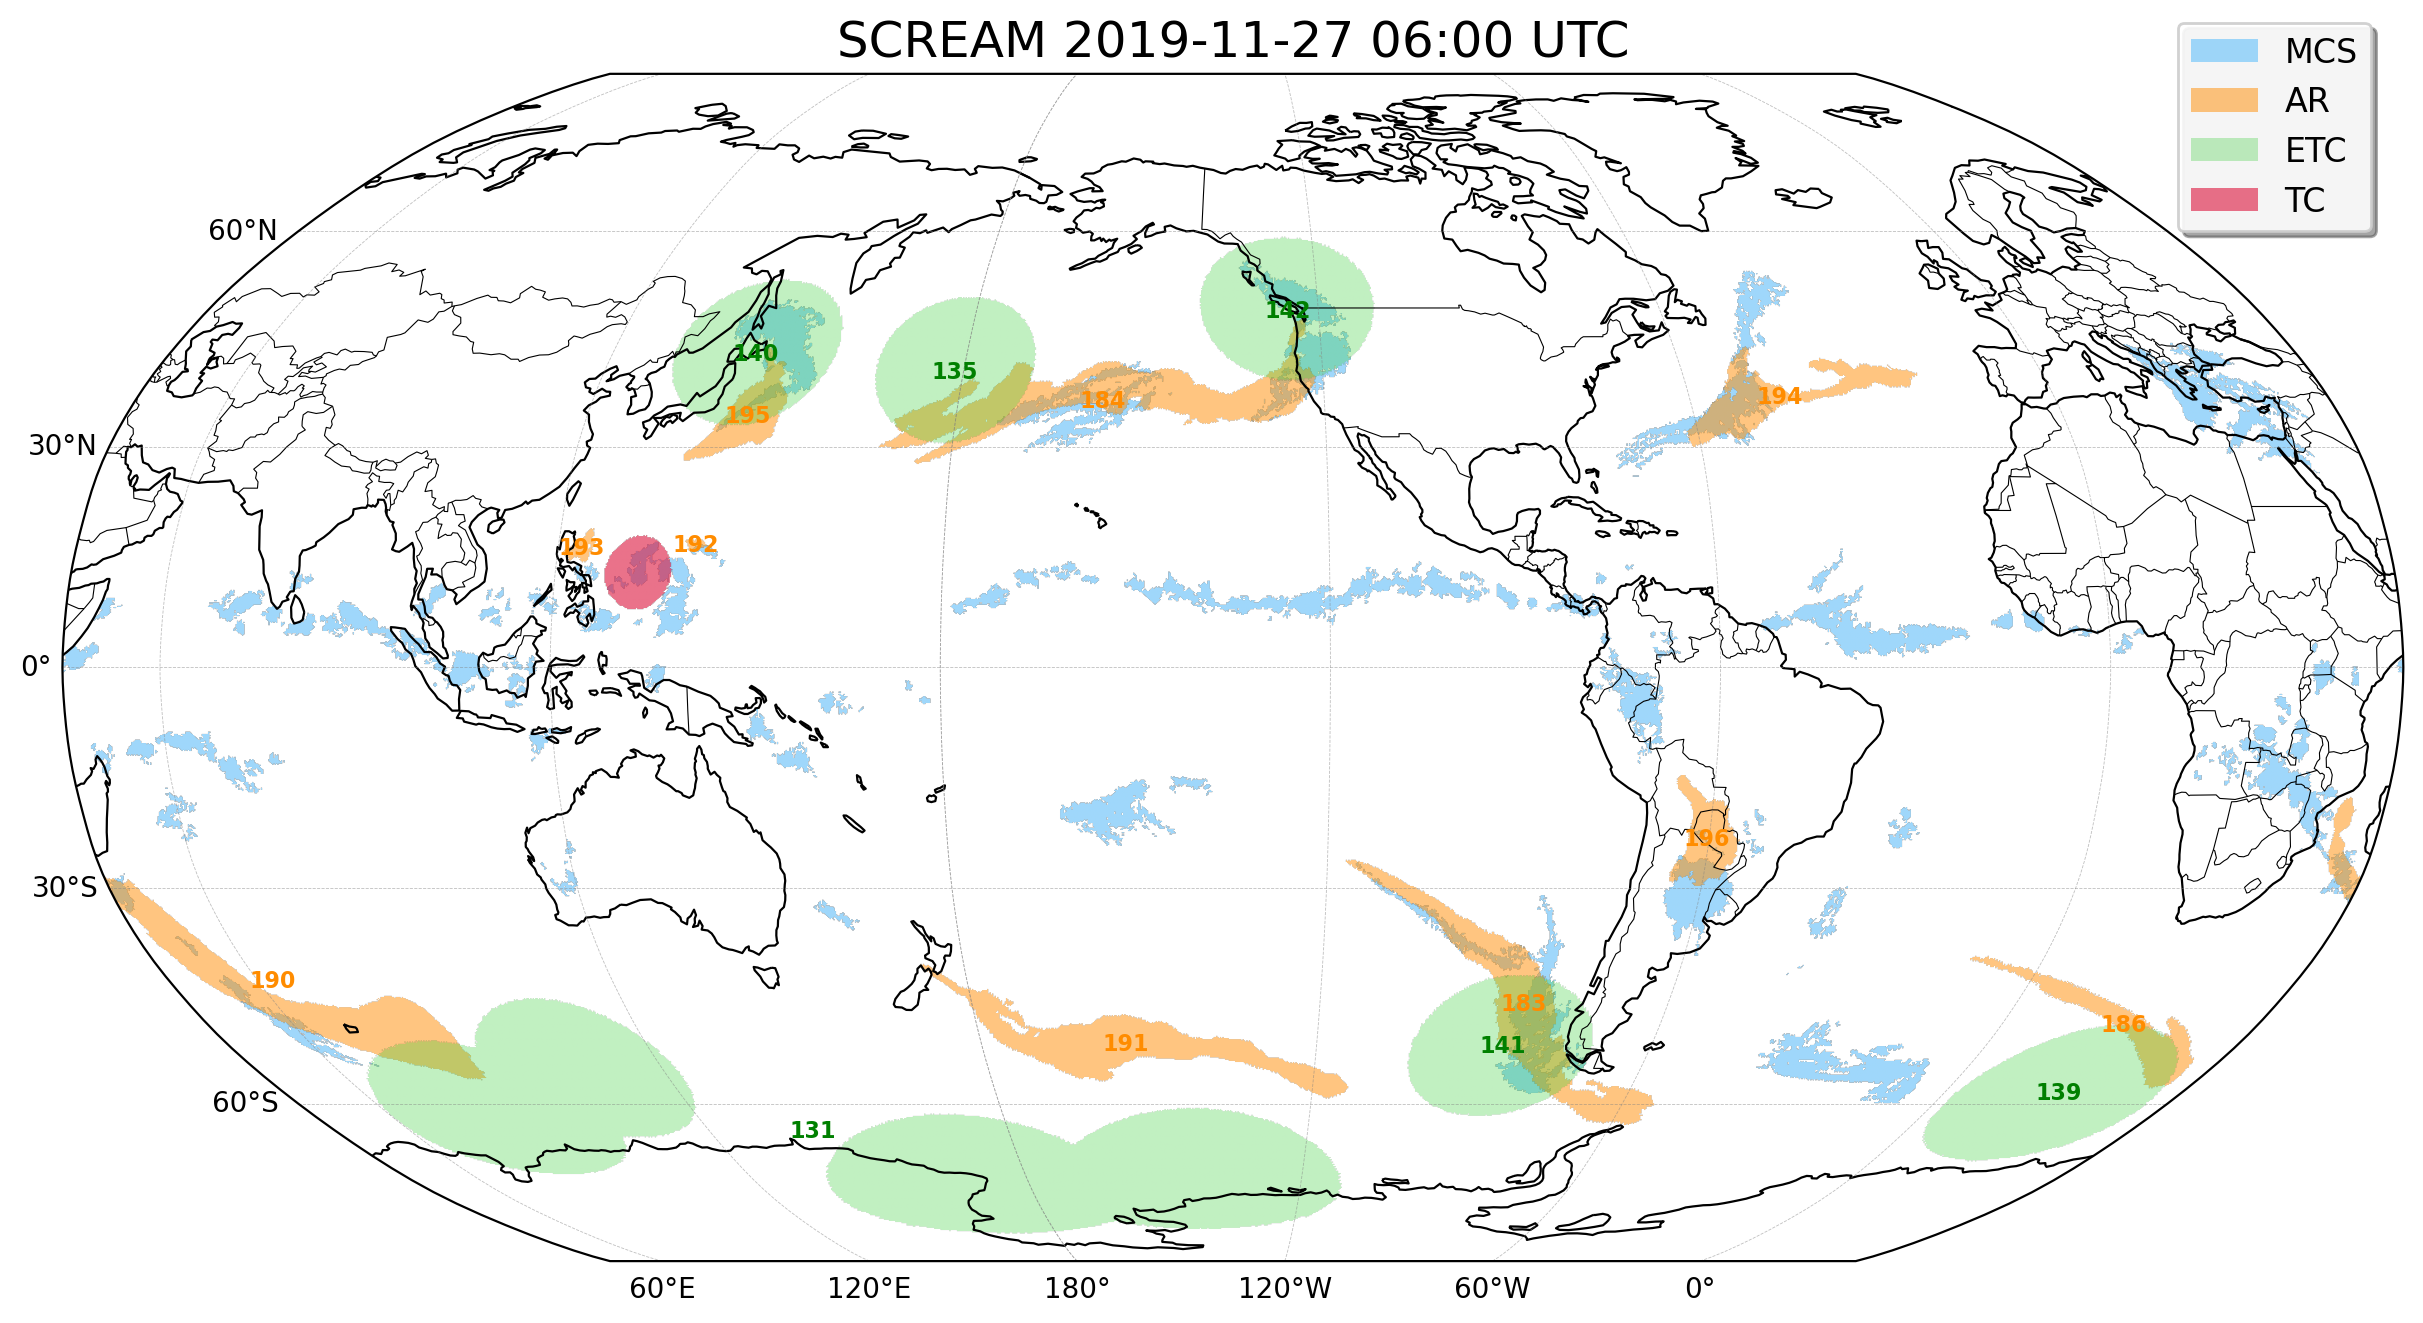

In [5]:
_time = ds.time.sel(time=tm, method='nearest')
time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{source_name.upper()} {time_label}"
figname = f'{figdir}{source_name}_allmasks_{time_str}.png'

# Example with custom colors and figure saving
custom_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
# Example with custom alphas and font sizes
custom_alphas = {
    'mcs': 0.8,    # More opaque for MCS
    'ar': 0.5,     # More transparent for AR
    'etc': 0.3,    # Medium transparency for ETC
    'tc': 0.6      # Very opaque for TC
}
title_fontsize = 18
legend_fontsize = 12

fig, ax = plot_all_feature_masks(
    _ds, 
    title=title_with_time, 
    figsize=(12, 6.75),
    colors=custom_colors,
    alphas=custom_alphas,
    title_fontsize=title_fontsize,
    legend_fontsize=legend_fontsize,
    figname=figname,
    dpi=200,
    show_track_labels=True,
    track_fontsize=8
)
plt.show()

In [6]:
# ar_186 = _ds.ar_mask.where(_ds.ar_mask == 186)
# egh.healpix_show(ar_186.where(ar_186 > 0))
# np.count_nonzero(_ds.ar_mask == 186)

## Core Analysis Functions

These functions implement the improved overlap detection algorithms with meteorological awareness.

In [7]:
def find_overlapping_tracks_and_pairs(mask1, mask2, binary_sum_mask, 
                                     thresh1=0.1, thresh2=0.1, overlap_threshold=1,
                                     feature1_name="Feature1", feature2_name="Feature2", verbose=True):
    """
    Find overlapping tracks for both feature types AND their valid pairs in a single pass.
    
    Parameters:
    -----------
    mask1, mask2 : xarray.DataArray
        Track masks for the two feature types to analyze
    binary_sum_mask : xarray.DataArray
        Binary summation mask indicating overlap regions
    thresh1, thresh2 : float
        Minimum overlap fractions for each feature type
    overlap_threshold : int, default=1
        Minimum value in binary_sum_mask for overlap detection
    feature1_name, feature2_name : str
        Names of the feature types for reporting
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Combined results containing:
        - 'feature1_results': overlap results for feature1 (like find_overlapping_tracks)
        - 'feature2_results': overlap results for feature2 (like find_overlapping_tracks) 
        - 'valid_pairs': list of (track1_id, track2_id) tuples
        - 'feature1_tracks': numpy array of feature1 track IDs in valid pairs
        - 'feature2_tracks': numpy array of feature2 track IDs in valid pairs
        - 'pair_details': detailed information about each pair
    """
    if verbose:
        print(f"Finding {feature1_name}-{feature2_name} overlaps and pairs with thresholds: {thresh1:.1%}, {thresh2:.1%}")
    
    # Step 1: Find overlap condition (shared between both features)
    overlap_condition = (binary_sum_mask > overlap_threshold) & ~np.isnan(binary_sum_mask) & ~np.isnan(mask1) & ~np.isnan(mask2)
    
    # Step 2: Get overlapping tracks for both features in one pass
    # Feature 1 overlapping tracks
    tracks1_in_overlap, overlap1_counts = np.unique(mask1.where(overlap_condition), return_counts=True)
    valid_mask1 = ~np.isnan(tracks1_in_overlap)
    tracks1_in_overlap = tracks1_in_overlap[valid_mask1]
    overlap1_counts = overlap1_counts[valid_mask1]
    
    # Feature 2 overlapping tracks
    tracks2_in_overlap, overlap2_counts = np.unique(mask2.where(overlap_condition), return_counts=True)
    valid_mask2 = ~np.isnan(tracks2_in_overlap)
    tracks2_in_overlap = tracks2_in_overlap[valid_mask2]
    overlap2_counts = overlap2_counts[valid_mask2]
    
    # Step 3: Get total pixel counts for all tracks (shared computation)
    unique_tracks1, total1_counts = np.unique(mask1, return_counts=True)
    unique_tracks2, total2_counts = np.unique(mask2, return_counts=True)
    
    track1_counts_dict = dict(zip(unique_tracks1, total1_counts))
    track2_counts_dict = dict(zip(unique_tracks2, total2_counts))
    
    # Step 4: Calculate overlap fractions for both features
    total1_pixel_counts = np.array([track1_counts_dict.get(track, 0) for track in tracks1_in_overlap])
    total2_pixel_counts = np.array([track2_counts_dict.get(track, 0) for track in tracks2_in_overlap])
    
    overlap1_fractions = overlap1_counts / total1_pixel_counts
    overlap2_fractions = overlap2_counts / total2_pixel_counts
    
    # Step 5: Find tracks exceeding overlap thresholds
    threshold1_mask = overlap1_fractions >= thresh1
    threshold2_mask = overlap2_fractions >= thresh2
    
    tracks1_exceeding = tracks1_in_overlap[threshold1_mask]
    tracks2_exceeding = tracks2_in_overlap[threshold2_mask]
    
    # Step 6: EFFICIENT PAIR FINDING using vectorized operations
    # Create masks for tracks that exceed thresholds
    mask1_qualifying = np.isin(mask1, tracks1_exceeding)
    mask2_qualifying = np.isin(mask2, tracks2_exceeding)
    
    # Find pixels where both qualifying tracks overlap
    mutual_overlap_pixels = mask1_qualifying & mask2_qualifying & overlap_condition
    
    if mutual_overlap_pixels.sum().compute().item() > 0:
        # Get track pairs that actually overlap spatially
        track1_values = mask1.where(mutual_overlap_pixels).values
        track2_values = mask2.where(mutual_overlap_pixels).values
        
        # Remove NaN values and create coordinate pairs
        valid_overlap = ~np.isnan(track1_values) & ~np.isnan(track2_values)
        track1_valid = track1_values[valid_overlap]
        track2_valid = track2_values[valid_overlap]
        
        # Find unique pairs using numpy operations
        pair_coords = np.column_stack([track1_valid, track2_valid])
        unique_pairs = np.unique(pair_coords, axis=0)
        
        valid_pairs = [(int(pair[0]), int(pair[1])) for pair in unique_pairs]
    else:
        valid_pairs = []
    
    # Step 7: Create detailed results (similar to original functions)
    overlap1_fractions_dict = {tracks1_in_overlap[i]: overlap1_fractions[i] for i in range(len(tracks1_in_overlap))}
    overlap2_fractions_dict = {tracks2_in_overlap[i]: overlap2_fractions[i] for i in range(len(tracks2_in_overlap))}
    
    # Create pair details
    pair_details = {}
    for track1, track2 in valid_pairs:
        # Count overlap pixels for this specific pair
        track1_pixels = (mask1 == track1)
        track2_pixels = (mask2 == track2)
        pair_overlap = track1_pixels & track2_pixels & overlap_condition
        overlap_pixel_count = pair_overlap.sum().compute().item()
        
        pair_details[(track1, track2)] = {
            'overlap_pixels': overlap_pixel_count,
            'track1_fraction': overlap1_fractions_dict.get(track1, 0),
            'track2_fraction': overlap2_fractions_dict.get(track2, 0)
        }
    
    # Extract unique track lists from valid pairs
    if valid_pairs:
        paired_feature1_tracks = np.unique([pair[0] for pair in valid_pairs])
        paired_feature2_tracks = np.unique([pair[1] for pair in valid_pairs])
    else:
        paired_feature1_tracks = np.array([])
        paired_feature2_tracks = np.array([])
    
    if verbose:
        print(f"Feature1 ({feature1_name}): {len(tracks1_exceeding)} tracks exceed {thresh1:.1%} threshold")
        print(f"Feature2 ({feature2_name}): {len(tracks2_exceeding)} tracks exceed {thresh2:.1%} threshold")
        print(f"Found {len(valid_pairs)} valid pairs with spatial overlap")
        if len(valid_pairs) > 0 and len(valid_pairs) <= 10:
            print(f"  Pairs: {valid_pairs}")
    
    return {
        'feature1_results': {
            'tracks_exceeding_threshold': tracks1_exceeding,
            'overlap_fractions': overlap1_fractions_dict,
            'total_tracks_analyzed': len(unique_tracks1),
            'threshold_info': {'min_overlap_fraction': thresh1, 'overlap_threshold': overlap_threshold}
        },
        'feature2_results': {
            'tracks_exceeding_threshold': tracks2_exceeding,
            'overlap_fractions': overlap2_fractions_dict,
            'total_tracks_analyzed': len(unique_tracks2),
            'threshold_info': {'min_overlap_fraction': thresh2, 'overlap_threshold': overlap_threshold}
        },
        'valid_pairs': valid_pairs,
        'feature1_tracks': paired_feature1_tracks,
        'feature2_tracks': paired_feature2_tracks,
        'pair_details': pair_details
    }

print("✅ find_overlapping_tracks_and_pairs() function defined")

✅ find_overlapping_tracks_and_pairs() function defined


In [8]:
def find_true_3way_overlaps(mcs_mask, ar_mask, etc_mask, binary_sum_mask,
                          mcs_thresh=0.2, ar_thresh=0.1, etc_thresh=0.0, verbose=True):
    """
    Find tracks that have true 3-way overlaps with mutual spatial verification.
    
    This function ensures that all three features actually overlap spatially,
    not just that they individually exceed thresholds in 3-way regions.
    
    Parameters:
    -----------
    mcs_mask, ar_mask, etc_mask : xarray.DataArray
        Track masks for the three feature types
    binary_sum_mask : xarray.DataArray
        Binary summation mask where values == 3 indicate true 3-way overlaps
    mcs_thresh, ar_thresh, etc_thresh : float
        Minimum overlap fractions for each feature type
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Results containing validated 3-way overlaps with mutual verification
    """
    if verbose:
        print("Finding true 3-way overlaps with mutual spatial verification...")
    
    # Create 3-way overlap mask (only where all 3 features overlap)
    threeway_mask = (binary_sum_mask == 3).astype(int)
    threeway_pixels = threeway_mask.sum().compute().item()
    
    if verbose:
        print(f"Total 3-way overlap pixels: {threeway_pixels}")
    
    if threeway_pixels == 0:
        return {
            'mcs_tracks': np.array([]),
            'ar_tracks': np.array([]),
            'etc_tracks': np.array([]),
            'validated_triplets': [],
            'triplet_details': {}
        }
    
    # Find all tracks that have any presence in 3-way regions
    mcs_in_3way = np.unique(mcs_mask.values[threeway_mask > 0])
    mcs_in_3way = mcs_in_3way[mcs_in_3way > 0]
    
    ar_in_3way = np.unique(ar_mask.values[threeway_mask > 0])
    ar_in_3way = ar_in_3way[ar_in_3way > 0]
    
    etc_in_3way = np.unique(etc_mask.values[threeway_mask > 0])
    etc_in_3way = etc_in_3way[etc_in_3way > 0]
    
    validated_triplets = []
    triplet_details = {}
    valid_mcs = []
    valid_ar = []
    valid_etc = []
    
    # For each potential triplet, verify mutual overlap and thresholds
    for mcs_id in mcs_in_3way:
        for ar_id in ar_in_3way:
            for etc_id in etc_in_3way:
                # Get pixels for each track
                mcs_pixels = (mcs_mask == mcs_id)
                ar_pixels = (ar_mask == ar_id)
                etc_pixels = (etc_mask == etc_id)
                
                # Find the intersection of all three tracks in 3-way regions
                mutual_overlap = mcs_pixels & ar_pixels & etc_pixels & (threeway_mask > 0)
                overlap_count = mutual_overlap.sum().compute().item()
                
                if overlap_count > 0:
                    # Calculate overlap fractions for each track
                    mcs_total = mcs_pixels.sum().compute().item()
                    ar_total = ar_pixels.sum().compute().item()
                    etc_total = etc_pixels.sum().compute().item()
                    
                    mcs_fraction = overlap_count / mcs_total if mcs_total > 0 else 0
                    ar_fraction = overlap_count / ar_total if ar_total > 0 else 0
                    etc_fraction = overlap_count / etc_total if etc_total > 0 else 0
                    
                    # Check if all tracks meet their thresholds
                    if (mcs_fraction >= mcs_thresh and 
                        ar_fraction >= ar_thresh and 
                        etc_fraction >= etc_thresh):
                        
                        triplet = (mcs_id, ar_id, etc_id)
                        validated_triplets.append(triplet)
                        valid_mcs.append(mcs_id)
                        valid_ar.append(ar_id)
                        valid_etc.append(etc_id)
                        
                        triplet_details[triplet] = {
                            'overlap_pixels': overlap_count,
                            'mcs_fraction': mcs_fraction,
                            'ar_fraction': ar_fraction,
                            'etc_fraction': etc_fraction
                        }
    
    # Remove duplicates
    valid_mcs = np.unique(valid_mcs)
    valid_ar = np.unique(valid_ar)
    valid_etc = np.unique(valid_etc)
    
    if verbose:
        print(f"Validated 3-way overlaps:")
        print(f"  {len(validated_triplets)} triplets found")
        print(f"  MCS tracks: {len(valid_mcs)} - {valid_mcs}")
        print(f"  AR tracks: {len(valid_ar)} - {valid_ar}")
        print(f"  ETC tracks: {len(valid_etc)} - {valid_etc}")
        if len(validated_triplets) > 0 and len(validated_triplets) <= 5:
            print(f"  Triplets: {validated_triplets}")
    
    return {
        'mcs_tracks': valid_mcs,
        'ar_tracks': valid_ar,
        'etc_tracks': valid_etc,
        'validated_triplets': validated_triplets,
        'triplet_details': triplet_details
    }

print("✅ find_true_3way_overlaps() function defined")

✅ find_true_3way_overlaps() function defined


## Binary Mask Creation

Create binary masks and summation masks for overlap detection.

In [9]:
# CREATE BINARY MASKS FOR OVERLAP ANALYSIS
print("Creating binary masks for overlap analysis...")

# Create binary masks (1 where feature exists, 0 elsewhere)
mcs_binary = xr.where(_ds.mcs_mask > 0, 1, 0)
ar_binary = xr.where(_ds.ar_mask > 0, 1, 0)
etc_binary = xr.where(_ds.etc_mask > 0, 1, 0)

# Create pairwise summation masks
mcs_ar_sum = mcs_binary + ar_binary
ar_etc_sum = ar_binary + etc_binary  
mcs_etc_sum = mcs_binary + etc_binary

# Create 3-way summation mask
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

print("✅ Binary masks created successfully")

# Display overlap statistics
print(f"\nOverlap region statistics:")
print(f"  MCS-AR 2-way overlaps: {(mcs_ar_sum == 2).sum().compute().item()} pixels")
print(f"  AR-ETC 2-way overlaps: {(ar_etc_sum == 2).sum().compute().item()} pixels")
print(f"  MCS-ETC 2-way overlaps: {(mcs_etc_sum == 2).sum().compute().item()} pixels")
print(f"  3-way overlaps: {(mcs_ar_etc_sum == 3).sum().compute().item()} pixels")

Creating binary masks for overlap analysis...
✅ Binary masks created successfully

Overlap region statistics:
  MCS-AR 2-way overlaps: 4615 pixels
  AR-ETC 2-way overlaps: 5777 pixels
  MCS-ETC 2-way overlaps: 4111 pixels
  3-way overlaps: 1328 pixels


## Meteorologically-Informed Overlap Analysis

Apply the improved thresholds that respect atmospheric scale hierarchy.

In [10]:
# METEOROLOGICALLY-INFORMED OVERLAP ANALYSIS
print("Performing meteorologically-informed overlap analysis...")
print("="*60)

# Define thresholds based on atmospheric scale hierarchy
mcs_thresh = 0.20  # 20% - smallest features, need substantial overlap
ar_thresh = 0.10   # 10% - medium features
etc_thresh_2way = 0.05  # 5% - largest features for 2-way overlaps
etc_thresh_3way = 0.00  # 0% - environmental context for 3-way overlaps

print(f"Overlap thresholds:")
print(f"  MCS: {mcs_thresh:.0%} (all scenarios)")
print(f"  AR: {ar_thresh:.0%} (all scenarios)")
print(f"  ETC: {etc_thresh_2way:.0%} (2-way), {etc_thresh_3way:.0%} (3-way)")

# 1. 3-WAY OVERLAPS WITH MUTUAL SPATIAL VERIFICATION
print(f"\n1. 3-WAY OVERLAPS:")
print("-" * 20)

# Use the new validated 3-way overlap function
validated_3way = find_true_3way_overlaps(
    _ds.mcs_mask, _ds.ar_mask, _ds.etc_mask, mcs_ar_etc_sum,
    mcs_thresh, ar_thresh, etc_thresh_3way, verbose=True
)

# Extract validated tracks
mcs_tracks_with_ar_etc_overlap = validated_3way['mcs_tracks']
ar_tracks_with_mcs_etc_overlap = validated_3way['ar_tracks']
etc_tracks_with_mcs_ar_overlap = validated_3way['etc_tracks']
validated_triplets = validated_3way['validated_triplets']

print(f"\nValidated 3-way overlap results:")
print(f"  MCS tracks: {len(mcs_tracks_with_ar_etc_overlap)}")
print(f"  AR tracks: {len(ar_tracks_with_mcs_etc_overlap)}")
print(f"  ETC tracks: {len(etc_tracks_with_mcs_ar_overlap)}")
print(f"  Total triplets: {len(validated_triplets)}")

# 2. 2-WAY PAIRS WITH EXCLUSION OF 3-WAY PARTICIPANTS
print(f"\n2. 2-WAY PAIRS (excluding 3-way participants):")
print("-" * 45)

# Find all potential 2-way overlaps using optimized function
mcs_ar_pairs_all = find_overlapping_tracks_and_pairs(_ds.mcs_mask, _ds.ar_mask, mcs_ar_sum,
                                                    mcs_thresh, ar_thresh, overlap_threshold=0,
                                                    feature1_name="MCS", feature2_name="AR")

ar_etc_pairs_all = find_overlapping_tracks_and_pairs(_ds.ar_mask, _ds.etc_mask, ar_etc_sum,
                                                    ar_thresh, etc_thresh_2way, overlap_threshold=0,
                                                    feature1_name="AR", feature2_name="ETC")

mcs_etc_pairs_all = find_overlapping_tracks_and_pairs(_ds.mcs_mask, _ds.etc_mask, mcs_etc_sum,
                                                     mcs_thresh, etc_thresh_2way, overlap_threshold=0,
                                                     feature1_name="MCS", feature2_name="ETC")

# Filter out tracks that ACTUALLY EXCEED 3-way thresholds (not just participate)
mcs_ar_pairs_2way_only = [pair for pair in mcs_ar_pairs_all['valid_pairs']
                         if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                         and pair[1] not in ar_tracks_with_mcs_etc_overlap]

ar_etc_pairs_2way_only = [pair for pair in ar_etc_pairs_all['valid_pairs']
                         if pair[0] not in ar_tracks_with_mcs_etc_overlap 
                         and pair[1] not in etc_tracks_with_mcs_ar_overlap]

mcs_etc_pairs_2way_only = [pair for pair in mcs_etc_pairs_all['valid_pairs']
                          if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                          and pair[1] not in etc_tracks_with_mcs_ar_overlap]

print(f"\n2-way pair results (excluding 3-way participants):")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")

# Debug output to check specific tracks
print(f"\nDebug - Validated 3-way tracks:")
print(f"  MCS (>= {mcs_thresh*100}%): {mcs_tracks_with_ar_etc_overlap}")
print(f"  AR (>= {ar_thresh*100}%): {ar_tracks_with_mcs_etc_overlap}")
print(f"  ETC (> {etc_thresh_3way*100}%): {etc_tracks_with_mcs_ar_overlap}")
if len(validated_triplets) > 0:
    print(f"  Validated triplets (MCS, AR, ETC): {validated_triplets}")

print(f"\n✅ Meteorologically-informed overlap analysis complete!")

Performing meteorologically-informed overlap analysis...
Overlap thresholds:
  MCS: 20% (all scenarios)
  AR: 10% (all scenarios)
  ETC: 5% (2-way), 0% (3-way)

1. 3-WAY OVERLAPS:
--------------------
Finding true 3-way overlaps with mutual spatial verification...
Total 3-way overlap pixels: 1328
Validated 3-way overlaps:
  1 triplets found
  MCS tracks: 1 - [15960.]
  AR tracks: 1 - [183]
  ETC tracks: 1 - [141]
  Triplets: [(np.float64(15960.0), np.int32(183), np.int32(141))]

Validated 3-way overlap results:
  MCS tracks: 1
  AR tracks: 1
  ETC tracks: 1
  Total triplets: 1

2. 2-WAY PAIRS (excluding 3-way participants):
---------------------------------------------
Finding MCS-AR overlaps and pairs with thresholds: 20.0%, 10.0%
Feature1 (MCS): 92 tracks exceed 20.0% threshold
Feature2 (AR): 7 tracks exceed 10.0% threshold
Found 16 valid pairs with spatial overlap
Finding AR-ETC overlaps and pairs with thresholds: 10.0%, 5.0%
Feature1 (AR): 10 tracks exceed 10.0% threshold
Feature2 

In [11]:
# EXTRACT TRACK LISTS FOR VISUALIZATION AND CHECK RESULTS
print("Extracting track lists for visualization...")

# Extract track lists from 2-way-only pairs for visualization
if mcs_ar_pairs_2way_only:
    mcs_tracks_paired_2way_only = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired_2way_only = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired_2way_only = np.array([])
    ar_tracks_paired_2way_only = np.array([])

if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar_2way_only = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_ar_2way_only = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs_2way_only = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_mcs_2way_only = np.array([])

print(f"Track lists extracted for visualization:")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)} pairs")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)} pairs")  
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)} pairs")
print(f"  3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC tracks")

print(f"\n✅ Track extraction complete!")

Extracting track lists for visualization...
Track lists extracted for visualization:
  MCS-AR pairs: 14 pairs
  AR-ETC pairs: 5 pairs
  MCS-ETC pairs: 3 pairs
  3-way overlaps: 1 MCS, 1 AR, 1 ETC tracks

✅ Track extraction complete!


In [12]:
ar_etc_pairs_2way_only

[(184, 135), (184, 142), (186, 139), (190, 131), (195, 140)]

In [13]:
mcs_etc_pairs_2way_only

[(16341, 140), (16450, 142), (16470, 142)]

## Create Visualization Masks

Generate the masks needed for the comprehensive 4-panel visualization.

In [14]:
# CREATE VISUALIZATION MASKS
print("Creating masks for comprehensive visualization...")

# Extract track lists from 2-way pairs for visualization
if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc = np.array([])
    etc_tracks_paired_with_ar = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc = np.array([])
    etc_tracks_paired_with_mcs = np.array([])

if mcs_ar_pairs_2way_only:
    mcs_tracks_paired = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired = np.array([])
    ar_tracks_paired = np.array([])

# Create 2-way pair masks
mcs_ar_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired), 
    _ds.mcs_mask, 
    0
)
ar_mcs_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired), 
    _ds.ar_mask, 
    0
)

ar_etc_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired_with_etc), 
    _ds.ar_mask, 
    0
)
etc_ar_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_ar), 
    _ds.etc_mask, 
    0
)

mcs_etc_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired_with_etc), 
    _ds.mcs_mask, 
    0
)
etc_mcs_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_mcs), 
    _ds.etc_mask, 
    0
)

# Create 3-way overlap masks
mcs_ar_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_etc_overlap), 
    _ds.mcs_mask, 
    0
)
ar_mcs_etc_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_etc_overlap), 
    _ds.ar_mask, 
    0
)
etc_mcs_ar_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_ar_overlap), 
    _ds.etc_mask, 
    0
)

print("✅ All visualization masks created successfully!")

print(f"\nMask verification:")
print(f"  2-way masks created for {len(mcs_ar_pairs_2way_only) + len(ar_etc_pairs_2way_only) + len(mcs_etc_pairs_2way_only)} total pairs")
print(f"  3-way masks: {(etc_mcs_ar_overlap_mask > 0).sum().item()} ETC pixels")

Creating masks for comprehensive visualization...
✅ All visualization masks created successfully!

Mask verification:
  2-way masks created for 22 total pairs
  3-way masks: 5971 ETC pixels


## Comprehensive 4-Panel Visualization

Final visualization showing all meteorological feature interactions with improved analysis.

Creating comprehensive 4-panel visualization...
Figure saved as: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_cof_20191127_0600.png


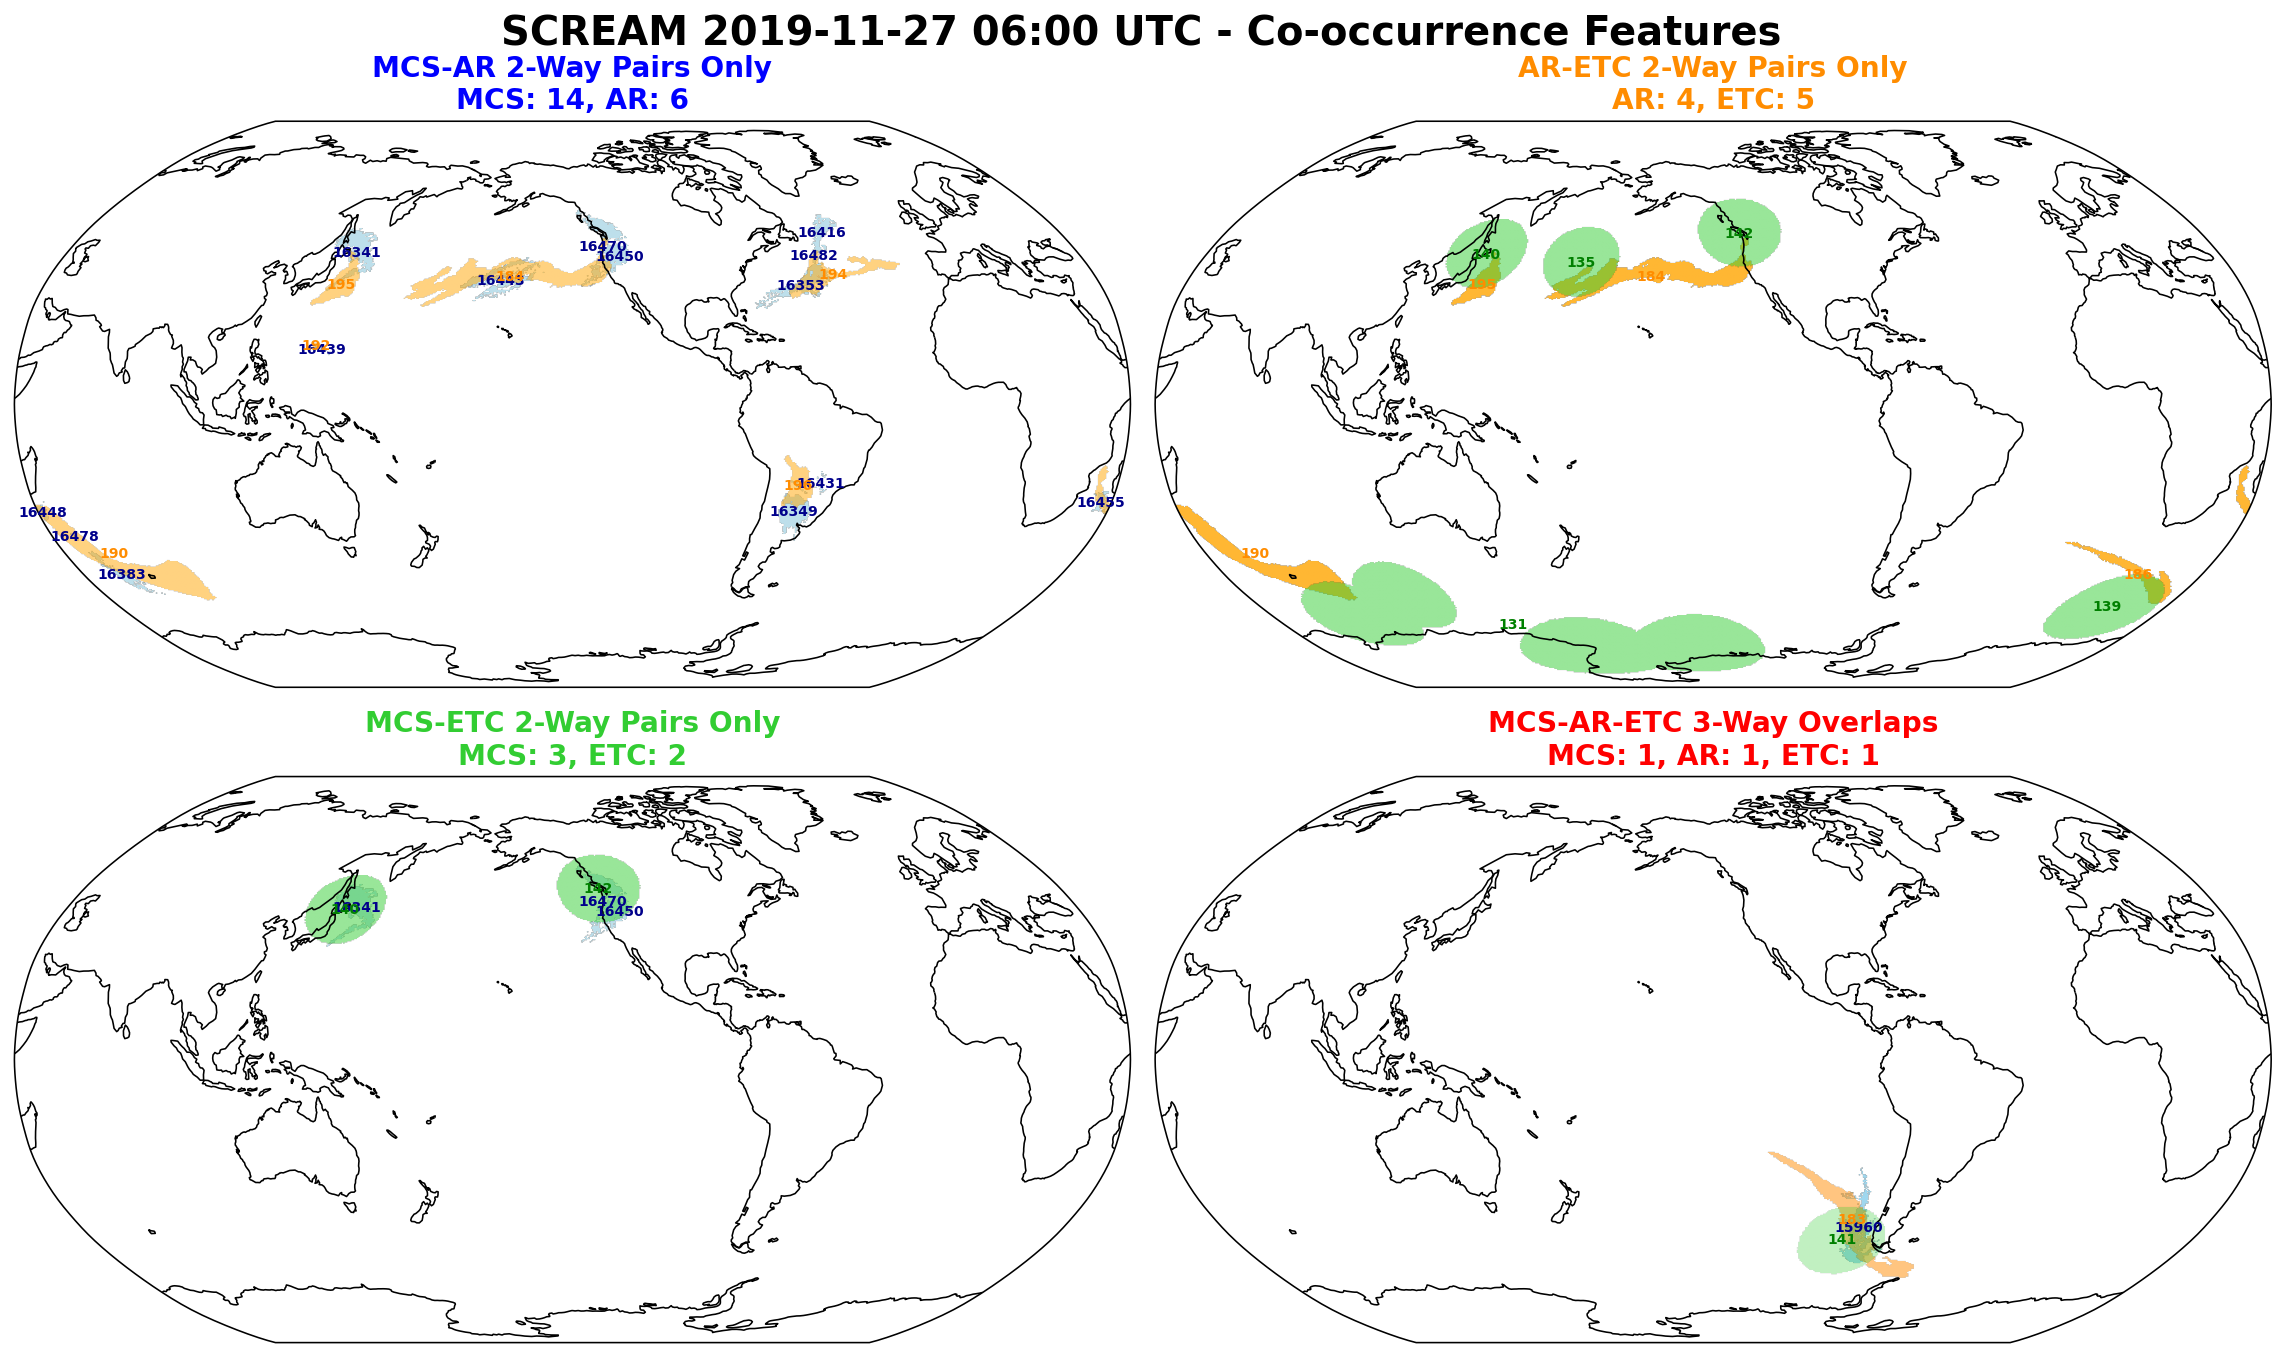


COMPREHENSIVE ANALYSIS SUMMARY:         
2-way MCS-AR pairs: 14
2-way AR-ETC pairs: 5
2-way MCS-ETC pairs: 3
3-way overlaps: 1 MCS, 1 AR, 1 ETC


In [15]:
# COMPREHENSIVE 4-PANEL VISUALIZATION WITH METEOROLOGICALLY-INFORMED ANALYSIS
print("Creating comprehensive 4-panel visualization...")

# Helper function for circular longitude averaging (handles dateline crossing)
def circular_lon_mean(lon_values):
    """Calculate circular mean for longitude values to handle dateline crossing."""
    # Convert to radians
    lon_rad = np.deg2rad(lon_values)
    # Calculate circular mean using complex numbers
    mean_complex = np.mean(np.exp(1j * lon_rad))
    # Convert back to degrees and ensure 0-360 range
    mean_lon = np.rad2deg(np.angle(mean_complex))
    if mean_lon < 0:
        mean_lon += 360
    return mean_lon

# Create datetime string for filename
datetime_string = time_str  # Already in YYYYMMDD_HHMM format

projection = ccrs.Robinson(central_longitude=-135)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10), 
                                             subplot_kw={"projection": projection})

# Add main title with source name and datetime
main_title = f"{source_name.upper()} {time_label} - Co-occurrence Features"
fig.suptitle(main_title, fontsize=20, fontweight='bold', y=0.97)

# Add coastlines and features to all axes
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    # ax.add_feature(cf.BORDERS, linewidth=0.4)

fontsize_tracks = 7
title_fontsize = 14

# Panel 1: MCS-AR 2-way pairs only
plt.sca(ax1)
if len(mcs_tracks_paired_2way_only) > 0:
    im_mcs_ar = egh.healpix_show(
        mcs_ar_overlap_mask_pairs.where(mcs_ar_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('lightblue'), dpi=144, alpha=0.8, ax=ax1)
if len(ar_tracks_paired_2way_only) > 0:
    im_ar_mcs = egh.healpix_show(
        ar_mcs_overlap_mask_pairs.where(ar_mcs_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('orange'), dpi=144, alpha=0.5, ax=ax1)

# Annotations for MCS-AR
for track_id in mcs_tracks_paired:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax1.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in ar_tracks_paired:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax1.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

ax1.set_title(f"MCS-AR 2-Way Pairs Only\nMCS: {len(mcs_tracks_paired)}, AR: {len(ar_tracks_paired)}", 
              fontsize=title_fontsize, fontweight='bold', color='blue')

# Panel 2: AR-ETC 2-way pairs only
plt.sca(ax2)
if len(ar_tracks_paired_with_etc_2way_only) > 0:
    im_ar_etc = egh.healpix_show(
        ar_etc_overlap_mask_pairs.where(ar_etc_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('orange'), dpi=144, alpha=0.8, ax=ax2)
if len(etc_tracks_paired_with_ar_2way_only) > 0:
    im_etc_ar = egh.healpix_show(
        etc_ar_overlap_mask_pairs.where(etc_ar_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.5, ax=ax2)

# Annotations for AR-ETC
for track_id in ar_tracks_paired_with_etc:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax2.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

for track_id in etc_tracks_paired_with_ar:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax2.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax2.set_title(f"AR-ETC 2-Way Pairs Only\nAR: {len(ar_tracks_paired_with_etc)}, ETC: {len(etc_tracks_paired_with_ar)}", 
              fontsize=title_fontsize, fontweight='bold', color='darkorange')

# Panel 3: MCS-ETC 2-way pairs only
plt.sca(ax3)
if len(mcs_tracks_paired_with_etc_2way_only) > 0:
    im_mcs_etc = egh.healpix_show(
        mcs_etc_overlap_mask_pairs.where(mcs_etc_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('lightblue'), dpi=144, alpha=0.8, ax=ax3)
if len(etc_tracks_paired_with_mcs_2way_only) > 0:
    im_etc_mcs = egh.healpix_show(
        etc_mcs_overlap_mask_pairs.where(etc_mcs_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.5, ax=ax3)

# Annotations for MCS-ETC
for track_id in mcs_tracks_paired_with_etc:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax3.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in etc_tracks_paired_with_mcs:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax3.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax3.set_title(f"MCS-ETC 2-Way Pairs Only\nMCS: {len(mcs_tracks_paired_with_etc)}, ETC: {len(etc_tracks_paired_with_mcs)}", 
              fontsize=title_fontsize, fontweight='bold', color='limegreen')

# Panel 4: 3-way overlaps
plt.sca(ax4)
im_mcs_3way = egh.healpix_show(
    mcs_ar_etc_overlap_mask.where(mcs_ar_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('skyblue'), dpi=144, alpha=0.8, ax=ax4)
im_ar_3way = egh.healpix_show(
    ar_mcs_etc_overlap_mask.where(ar_mcs_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('darkorange'), dpi=144, alpha=0.5, ax=ax4)
im_etc_3way = egh.healpix_show(
    etc_mcs_ar_overlap_mask.where(etc_mcs_ar_overlap_mask > 0),
    cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.3, ax=ax4)

# Annotations for 3-way overlaps
for track_id in mcs_tracks_with_ar_etc_overlap:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in ar_tracks_with_mcs_etc_overlap:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

for track_id in etc_tracks_with_mcs_ar_overlap:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax4.set_title(f"MCS-AR-ETC 3-Way Overlaps\nMCS: {len(mcs_tracks_with_ar_etc_overlap)}, AR: {len(ar_tracks_with_mcs_etc_overlap)}, ETC: {len(etc_tracks_with_mcs_ar_overlap)}", 
              fontsize=title_fontsize, fontweight='bold', color='red')

plt.tight_layout()

# Save the figure with the specified filename
save_filename = f"{figdir}{source_name}_cof_{datetime_string}.png"
plt.savefig(save_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved as: {save_filename}")

plt.show()

print(f"\n{'COMPREHENSIVE ANALYSIS SUMMARY:':<40}")
print("="*50)
print(f"2-way MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"2-way AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"2-way MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")
print(f"3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC")

# print(f"\n✅ Meteorologically-informed feature interaction analysis complete! 🎉")